In [96]:
import numpy as np
from sklearn import datasets
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import matplotlib.colors

In [97]:
data = datasets.load_digits()

In [98]:
data

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [99]:
dir(data)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [100]:
data.images.shape

(1797, 8, 8)

In [101]:
print(f"Il y a {len(data.target)} classe dans data.target = {np.unique(data['target'])}")

Il y a 1797 classe dans data.target = [0 1 2 3 4 5 6 7 8 9]


In [102]:
print(data.images[89])

[[ 0.  0. 13. 16. 15.  4.  0.  0.]
 [ 0.  0.  9.  8. 13. 16.  3.  0.]
 [ 0.  0.  0.  0. 13. 16.  7.  0.]
 [ 0.  0.  0.  1. 16. 12.  0.  0.]
 [ 0.  0.  0.  0. 15. 10.  0.  0.]
 [ 0.  0.  0.  0.  8. 15.  0.  0.]
 [ 0.  0.  3.  6. 15. 16.  7.  0.]
 [ 0.  0. 15. 16. 16. 11.  1.  0.]]


In [103]:
data.target[89]

3

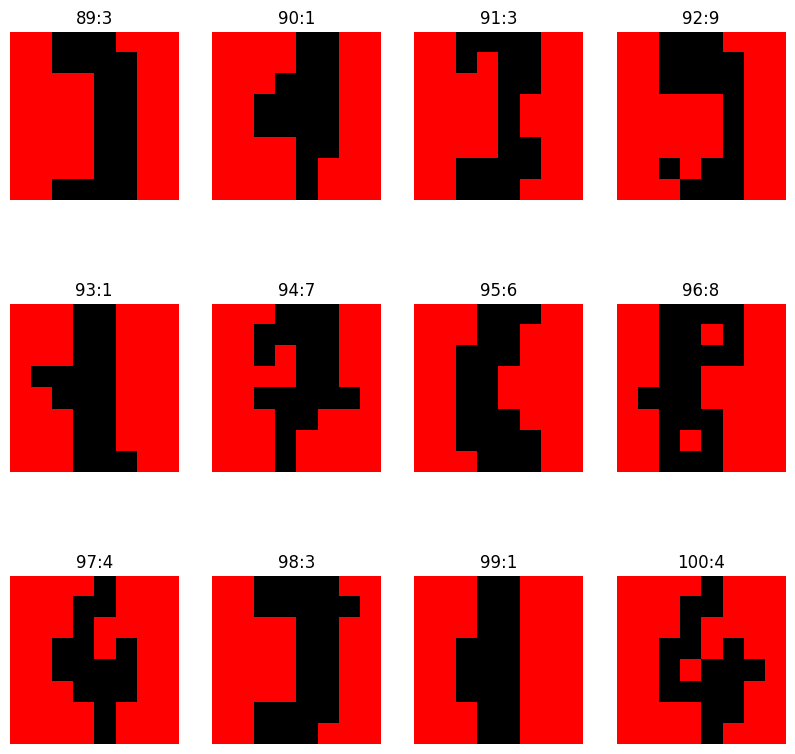

In [104]:
def plot_digits(start):    
    fig = plt.figure(figsize=(10,10))
    cmap = matplotlib.colors.ListedColormap(['red', 'black'])
    for im in range(12):
        plt.subplot(3,4,im+1)
        title = str(start+im) + ":" + str(data.target[start+im])
        plt.title(title)
        plt.imshow(data.images[start+im], cmap=cmap)     
        plt.axis('off')
    plt.show()
plot_digits(89)

In [105]:
y = data.target
x = data.images.reshape((len(data.images), -1))    #-1 signifie que la taille est calculée automatiquement en fo du nb d element dans data.images
x.shape # 1797 vecteurs de taille 64 = 8x8

(1797, 64)

In [106]:
x_train, y_train, x_test, y_test  = x[:1347], y[:1347], x[1347:], y[1347:]

In [107]:
mlp_classifier = MLPClassifier(hidden_layer_sizes=(20,), activation='logistic',  #une couche de 20 neurones
                    solver='sgd', tol=0.0001, n_iter_no_change=30, random_state=1, alpha=0.0001, learning_rate_init=.1, verbose=False)

In [108]:
mlp_classifier.fit(x_train,y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(20,),
              learning_rate_init=0.1, n_iter_no_change=30, random_state=1,
              solver='sgd')

In [109]:
type(mlp_classifier)

sklearn.neural_network._multilayer_perceptron.MLPClassifier

In [110]:
predictions = mlp_classifier.predict(x_test)

In [113]:
accuracy_score(y_test, predictions)

0.9244444444444444

In [112]:
print(f"     y_test[10:20] = {y_test[10:20]}")
print(f"predictions[10:20] = {predictions[10:20]}")

     y_test[10:20] = [1 5 0 9 5 2 8 2 0 0]
predictions[10:20] = [1 5 0 9 6 2 8 2 0 0]
